In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)


In [4]:
df = pd.read_csv("../data/Nassau Candy Distributor.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [5]:
print(df.shape)

df.info()

df.describe()

(10194, 18)
<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [6]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df[df["Sales"] > 0]

df = df[df["Gross Profit"] >= 0]

df["Units"] = df["Units"].fillna(1)

# Feature Engineering 

In [9]:
df["Gross Margin %"] = (
    df["Gross Profit"] /
    df["Sales"]
) * 100

In [10]:
df["Profit Per Unit"] = (
    df["Gross Profit"] /
    df["Units"]
)

In [11]:
total_sales = df["Sales"].sum()

df["Revenue Contribution %"] = (
    df["Sales"] /
    total_sales
) * 100

In [12]:
total_profit = df["Gross Profit"].sum()

df["Profit Contribution %"] = (
    df["Gross Profit"] /
    total_profit
) * 100

# Product Profitability Analysis

In [13]:
top_revenue = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_revenue

Product Name
Wonka Bar - Triple Dazzle Caramel    28485.00
Wonka Bar -Scrumdiddlyumptious       27874.80
Wonka Bar - Milk Chocolate           26867.75
Wonka Bar - Fudge Mallows            24890.40
Wonka Bar - Nutty Crunch Surprise    23574.95
Lickable Wallpaper                    7860.00
Kazookles                             1205.75
Wonka Gum                              597.50
Everlasting Gobstopper                 130.00
Fizzy Lifting Drinks                    78.75
Name: Sales, dtype: float64

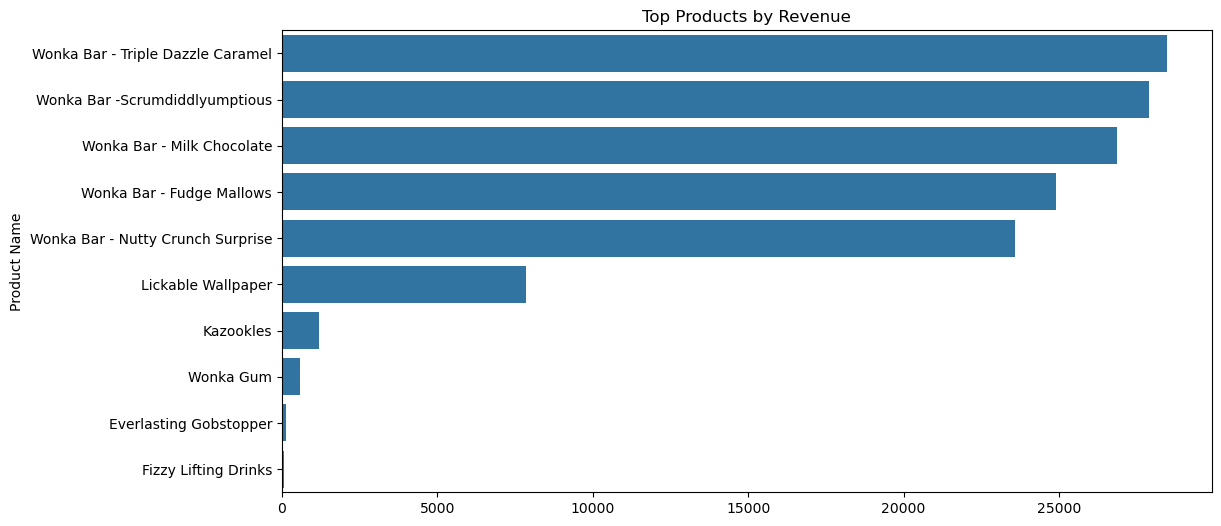

In [14]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_revenue.values,
    y=top_revenue.index
)

plt.title("Top Products by Revenue")
plt.show()

In [15]:
top_profit = (
    df.groupby("Product Name")["Gross Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_profit

Product Name
Wonka Bar -Scrumdiddlyumptious       19357.50
Wonka Bar - Triple Dazzle Caramel    18610.20
Wonka Bar - Milk Chocolate           17443.37
Wonka Bar - Nutty Crunch Surprise    16819.95
Wonka Bar - Fudge Mallows            16593.60
Lickable Wallpaper                    3930.00
Wonka Gum                              310.70
Everlasting Gobstopper                 104.00
Kazookles                               92.75
Hair Toffee                             59.50
Name: Gross Profit, dtype: float64

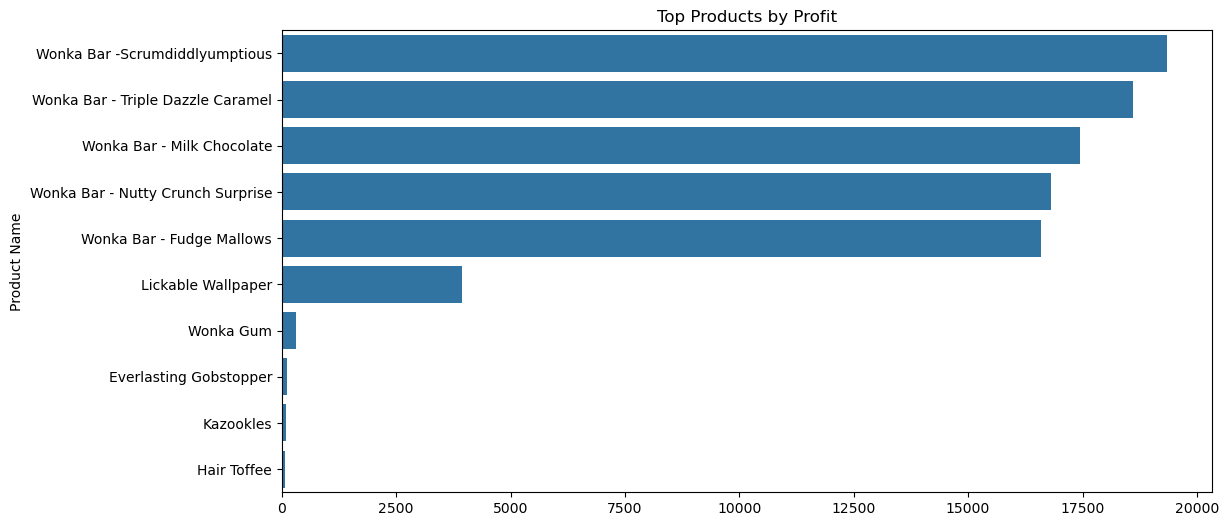

In [16]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_profit.values,
    y=top_profit.index
)

plt.title("Top Products by Profit")
plt.show()

# Margin leaderboard 

In [17]:
margin_rank = (
    df.groupby("Product Name")["Gross Margin %"]
      .mean()
      .sort_values(ascending=False)
)

margin_rank

Product Name
Everlasting Gobstopper               80.000000
Hair Toffee                          77.777778
Wonka Bar - Nutty Crunch Surprise    71.346705
Wonka Bar -Scrumdiddlyumptious       69.444444
Wonka Bar - Fudge Mallows            66.666667
Wonka Bar - Triple Dazzle Caramel    65.333333
Wonka Bar - Milk Chocolate           64.923077
Laffy Taffy                          62.311558
Fizzy Lifting Drinks                 60.000000
Wonka Gum                            52.000000
Lickable Wallpaper                   50.000000
Nerds                                46.666667
SweeTARTS                            46.666667
Fun Dip                              40.000000
Kazookles                             7.692308
Name: Gross Margin %, dtype: float64

# Division Performance Analysis

In [18]:
division_sales = (
    df.groupby("Division")["Sales"]
      .sum()
      .reset_index()
)

division_sales

,Division,Sales
0,Chocolate,131692.90
1,Other,9663.25
2,Sugar,427.48


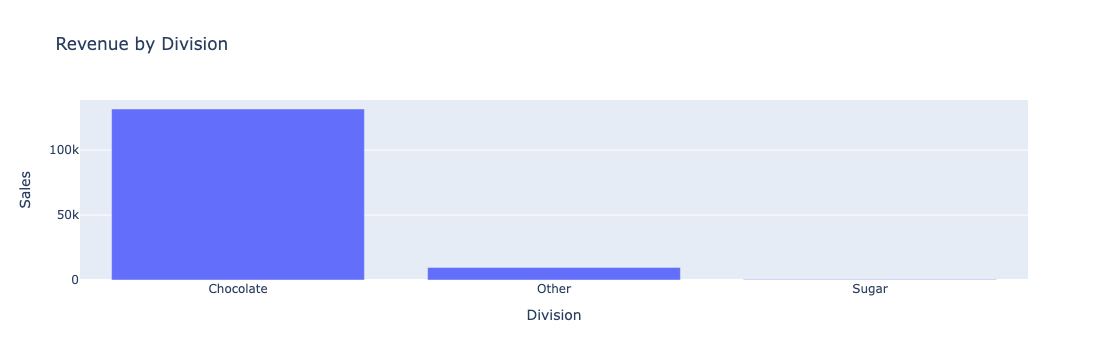

In [19]:
px.bar(
    division_sales,
    x="Division",
    y="Sales",
    title="Revenue by Division"
)

In [20]:
division_profit = (
    df.groupby("Division")["Gross Profit"]
      .sum()
      .reset_index()
)

division_profit

,Division,Gross Profit
0,Chocolate,88824.62
1,Other,4333.45
2,Sugar,284.73


In [22]:
division_margin = (
    df.groupby("Division")["Gross Margin %"]
      .mean()
      .reset_index()
)

division_margin

,Division,Gross Margin %
0,Chocolate,67.458162
1,Other,37.672457
2,Sugar,57.689001


# Cost Diagnostics

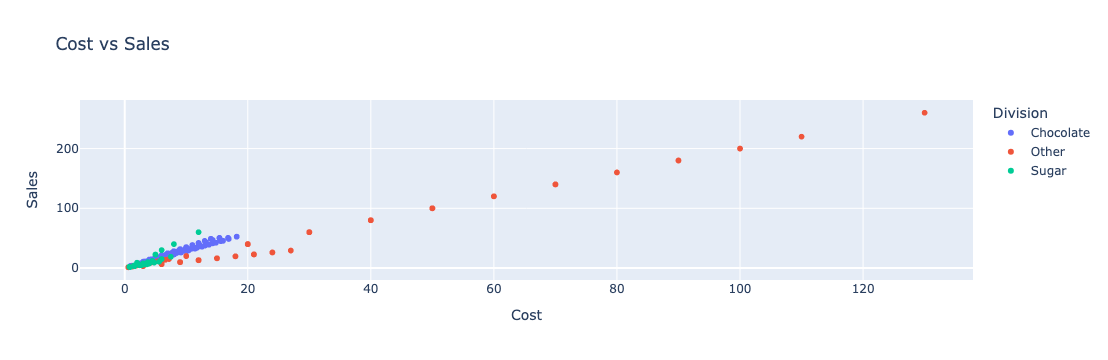

In [23]:
px.scatter(
    df,
    x="Cost",
    y="Sales",
    color="Division",
    hover_data=["Product Name"],
    title="Cost vs Sales"
)

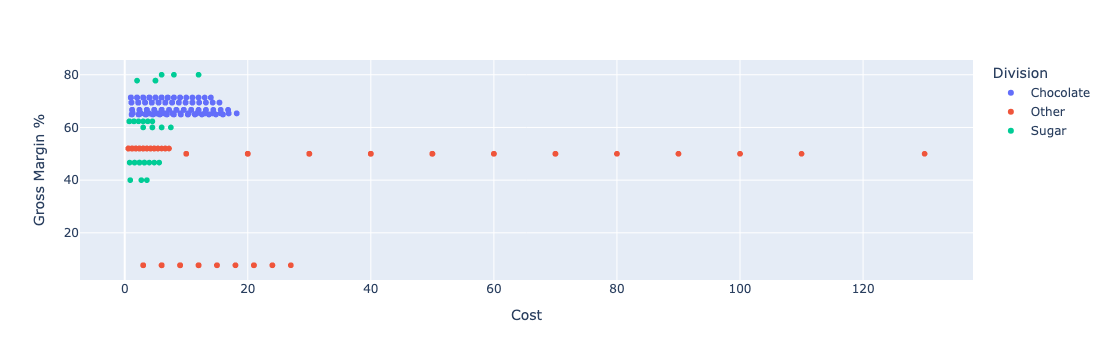

In [24]:
px.scatter(
    df,
    x="Cost",
    y="Gross Margin %",
    color="Division",
    hover_data=["Product Name"]
)

# Pareto Analysis

In [25]:
pareto_rev = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

pareto_rev["Revenue %"] = (
    pareto_rev["Sales"] /
    pareto_rev["Sales"].sum()
) * 100

pareto_rev["Cumulative %"] = (
    pareto_rev["Revenue %"]
).cumsum()

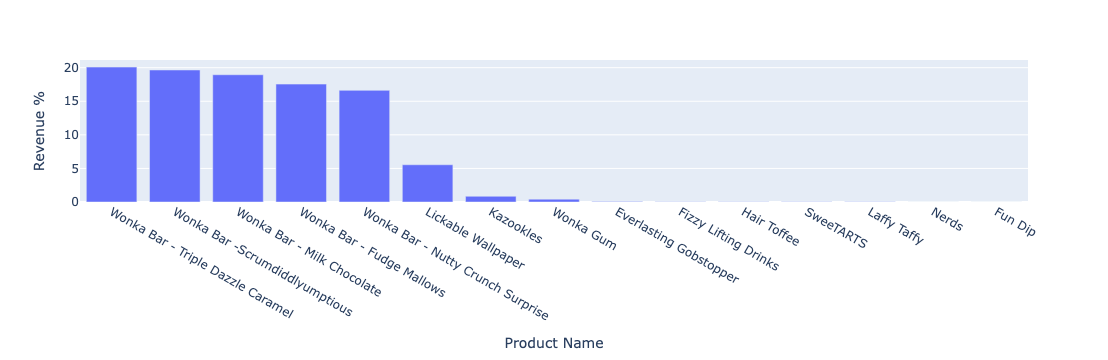

In [26]:
fig = px.bar(
    pareto_rev,
    x="Product Name",
    y="Revenue %"
)

fig.show()

In [27]:
pareto_profit = (
    df.groupby("Product Name")["Gross Profit"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

pareto_profit["Profit %"] = (
    pareto_profit["Gross Profit"]
    /
    pareto_profit["Gross Profit"].sum()
) * 100

pareto_profit["Cumulative %"] = (
    pareto_profit["Profit %"]
).cumsum()

# Time-Series Analysis

In [31]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True,
    errors="coerce"
)

In [34]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"]
)

monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="ME"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

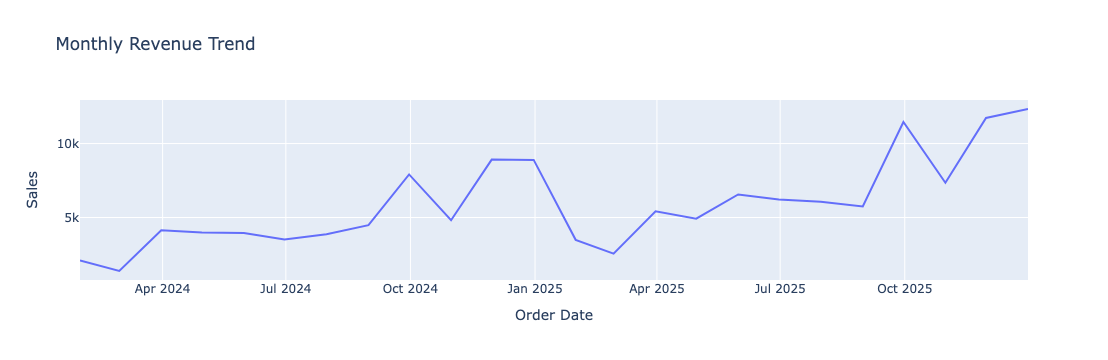

In [35]:
px.line(
    monthly_sales,
    x="Order Date",
    y="Sales",
    title="Monthly Revenue Trend"
)